<a href="https://colab.research.google.com/github/SalvadorGR23/Tesis/blob/main/EJEMPLO_MARKOWITZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**IMPORTACIÓN DE LIBRERÍAS**

In [1]:
!pip install PyPortfolioOpt

import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from datetime import date
from pypfopt import EfficientFrontier, plotting

pd.options.display.float_format = '{:,.5f}'.format

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 5.9 MB/s eta 0:00:00


#**ENTRADA DE DATOS**

##**PRECIOS HISTÓRICOS DE LOS ACTIVOS**
Como ejemplo; usaremos las acciones de:
* GENOMMA LAB INTERNACIONAL, S.A.B. DE C.V. (LABB.MX)
* GRUPO CARSO, S.A.B. DE C.V. (GCARSOA1.MX)
* WAL - MART DE MEXICO, S.A.B. DE C.V. (WALMEX.MX)
* QUÁLITAS CONTROLADORA, S.A.B. DE C.V. (Q.MX)

Y el periodo de análisi será de 2025-01-01 al 2025-12-31.

Extraemos los precios de cierre de los activos antes mencionado en el periodo descrito.

In [2]:
#Establecer Activos y Periodo de Análisis
tickers = ['LABB.MX', 'GCARSOA1.MX','WALMEX.MX','Q.MX']


fecha_inicio = "2025-01-01"
fecha_fin = "2026-01-01"

#Extracción de Datos
PRECIO_ACTIVOS = yf.download(tickers, start = fecha_inicio, end = fecha_fin)['Close']
PRECIO_ACTIVOS = PRECIO_ACTIVOS.dropna(how = 'all') #Eliminar días sin datos
PRECIO_ACTIVOS.rename_axis(None, axis = 1, inplace = True)
PRECIO_ACTIVOS.reset_index(inplace = True)
PRECIO_ACTIVOS['Date'] = pd.to_datetime(PRECIO_ACTIVOS['Date']).dt.date
PRECIO_ACTIVOS = PRECIO_ACTIVOS[['Date', 'LABB.MX', 'GCARSOA1.MX', 'WALMEX.MX', 'Q.MX']]
PRECIO_ACTIVOS

/tmp/ipykernel_214/1121054983.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  PRECIO_ACTIVOS = yf.download(tickers, start = fecha_inicio, end = fecha_fin)['Close']
[*********************100%***********************]  4 of 4 completed


,Date,LABB.MX,GCARSOA1.MX,WALMEX.MX,Q.MX
0,2025-01-02,24.70534,114.31873,53.71363,161.48491
1,2025-01-03,25.01295,111.27524,52.92616,157.24884
2,2025-01-06,25.10908,109.97088,53.47058,156.59201
3,2025-01-07,25.72431,111.68037,54.45250,155.16412
4,2025-01-08,25.08024,112.50053,54.31639,156.06845
...,...,...,...,...,...
246,2025-12-24,18.15000,119.86000,57.21000,189.50999
247,2025-12-26,18.07000,119.00000,57.19000,187.99001
248,2025-12-29,17.99000,119.50000,57.02000,191.09000
249,2025-12-30,17.90000,117.21000,56.28000,187.00000


#**CÁLCULO DE PARÁMETROS**

##**RENDIMIENTO ESPERADO DEL PORTAFOLIO DE MERCADO $\mathbb{E}[r_M]$**

In [10]:
RENDIMIENTOS_ACTIVOS = pd.DataFrame(PRECIO_ACTIVOS.set_index('Date').pct_change().mean(), columns=['Rendimiento Esperado'])
RENDIMIENTOS_ACTIVOS.reset_index(inplace=True)
RENDIMIENTOS_ACTIVOS.rename(columns = {'index': 'Activo'}, inplace = True)

RENDIMIENTOS_ACTIVOS

,Activo,Rendimiento Esperado
0,LABB.MX,-0.00105
1,GCARSOA1.MX,0.00042
2,WALMEX.MX,0.00032
3,Q.MX,0.00084


##**MATRIZ DE COVARIANZAS DE LOS ACTIVOS $\Sigma$**

In [4]:
MATRIZ_COVARIANZAS = PRECIO_ACTIVOS.drop(columns=['Date']).pct_change().cov()
MATRIZ_COVARIANZAS

,LABB.MX,GCARSOA1.MX,WALMEX.MX,Q.MX
LABB.MX,0.00048,0.00011,0.00003,0.00008
GCARSOA1.MX,0.00011,0.00057,0.00014,0.00017
WALMEX.MX,0.00003,0.00014,0.00031,0.00007
Q.MX,0.00008,0.00017,0.00007,0.00054


#**OPTIMIZACIÓN MARKOWITZ**

##**TASA LIBRE DE RIESGO ($r_f$)**
Para calcular la tasa libre de riesgo ($r_f$), ocupamos la API de Banxico para extraer los datos de la tasa de interés de los CETES a 28 días (en el periodo de análisis definido); para posteriormente calcular esta tasa libre de riesgo.

In [11]:
token_banxico = '6d1357d410effb5edad575bc9bba8f7e231048d7be672adfbfdd88849f8ca5c9'
id_cete = 'SF60633'

url = f'https://www.banxico.org.mx/SieAPIRest/service/v1/series/{id_cete}/datos/{fecha_inicio}/{fecha_fin}'
headers = {'Bmx-Token': token_banxico, 'Accept': 'application/json'}

response = requests.get(url, headers=headers)

CETES_28 = response.json()
CETES_28 = pd.DataFrame(CETES_28['bmx']['series'][0]['datos'])
CETES_28.columns = ['Date', 'Rate']
CETES_28['Date'] = pd.to_datetime(CETES_28['Date'], format='%d/%m/%Y')

CETES_28['Rate'].dropna()
CETES_28['Rate'] = CETES_28['Rate'].astype(float)
CETES_28['Rate'] = CETES_28['Rate']/100

#La tasa que ofrece CETES en cada subasta es anual, por lo que se convierte a una diaria
CETES_28['Rate'] = CETES_28['Rate']/252

#Calculo tasa libre de riesgo
tasa_libre_riesgo = CETES_28['Rate'].mean()
print('Tasa Libre de Riesgo: ', round(tasa_libre_riesgo, 4))

Tasa Libre de Riesgo:  0.0003


In [13]:
n_portfolios = 1_000_000
rendimientos = []
volatilidades = []
ratios_sharpe = []
dataframes_asignaciones = []

for _ in range(n_portfolios):
    pesos = np.random.random(len(tickers))
    pesos /= np.sum(pesos)
    ASIGNACIONES = pd.DataFrame(pesos, index = tickers, columns = ['Asignacion'])

    rendimiento = np.dot(pesos, RENDIMIENTOS_ACTIVOS['Rendimiento Esperado'].to_numpy())
    volatilidad = np.sqrt(np.dot(pesos.T, np.dot(MATRIZ_COVARIANZAS, pesos)))

    rendimientos.append(rendimiento)
    volatilidades.append(volatilidad)
    ratios_sharpe.append((rendimiento - tasa_libre_riesgo) / volatilidad)
    dataframes_asignaciones.append(ASIGNACIONES)

ASIGNACION = dataframes_asignaciones[np.argmax(ratios_sharpe)]
ASIGNACION = ASIGNACION.reset_index()
ASIGNACION.columns = ['Ticker', 'Asignacion']
ASIGNACION

,Ticker,Asignacion
0,LABB.MX,0.00044
1,GCARSOA1.MX,0.06727
2,WALMEX.MX,0.02517
3,Q.MX,0.90712


#**FRONTERA EFICIENTE**

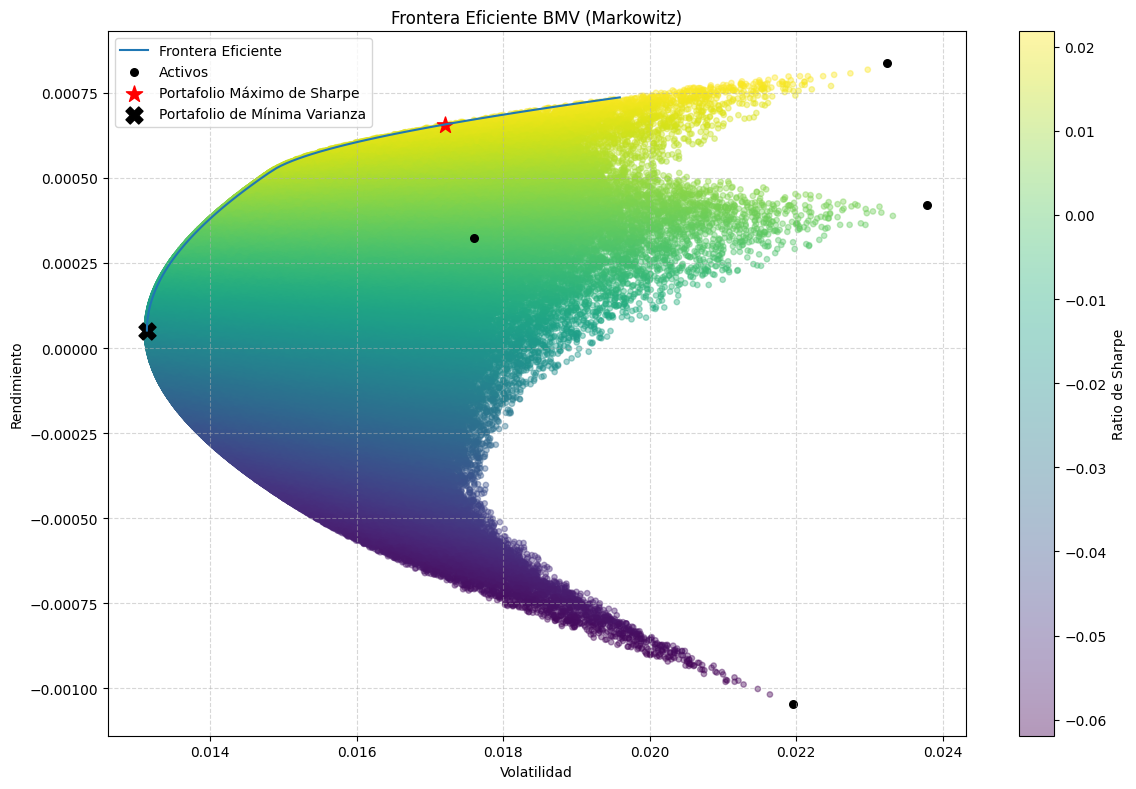

In [14]:
# 5. Visualización
fig, ax = plt.subplots(figsize = (12, 8))

# A. Dibujar la nube de carteras aleatorias
scatter = ax.scatter(volatilidades, rendimientos, c = ratios_sharpe, cmap = 'viridis', alpha = 0.4, marker = 'o', s = 15)
plt.colorbar(scatter, label = 'Ratio de Sharpe')

# B. Calcular y dibujar la Frontera Eficiente (línea)
ef = EfficientFrontier(RENDIMIENTOS_ACTIVOS['Rendimiento Esperado'].to_numpy(), MATRIZ_COVARIANZAS)
plotting.plot_efficient_frontier(ef, ax = ax, show_assets = True)

# C. Marcar puntos clave
# Cartera de Máximo Sharpe
ef_max = EfficientFrontier(RENDIMIENTOS_ACTIVOS['Rendimiento Esperado'].to_numpy(), MATRIZ_COVARIANZAS)
ef_max.max_sharpe()
ret_max, std_max, _ = ef_max.portfolio_performance()
ax.scatter(std_max, ret_max, marker = "*", s = 150, c = "red", label = "Portafolio Máximo de Sharpe")

# Cartera de Mínima Varianza
ef_min = EfficientFrontier(RENDIMIENTOS_ACTIVOS['Rendimiento Esperado'].to_numpy(), MATRIZ_COVARIANZAS)
ef_min.min_volatility()
ret_min, std_min, _ = ef_min.portfolio_performance()
ax.scatter(std_min, ret_min, marker = "X", s = 150, c = "black", label = "Portafolio de Mínima Varianza")

# Formato final
ax.set_title(f"Frontera Eficiente BMV (Markowitz)")
ax.set_xlabel("Volatilidad")
ax.set_ylabel("Rendimiento")

# Get current handles and labels from the plot to modify the legend
handles, labels = ax.get_legend_handles_labels()

# Modify labels
new_labels = []
for label in labels:
    if label == 'Efficient frontier':
        new_labels.append('Frontera Eficiente')
    elif label == 'assets':
        new_labels.append('Activos')
    else:
        new_labels.append(label)

ax.legend(handles, new_labels)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()